In [14]:
# SET PYTHONPATH to the parent directory 
import sys
import os
sys.path.append(os.path.abspath(".."))

In [64]:
import torch 
import numpy as np
from einops import rearrange, repeat
from hippy2d.complex_invariants_2d import get_complex_monomial
from hippy2d.optimal_invariant_cnn import MAX_ORDER
from hippy2d.flexibleconv2d import complex_power_moivre
from hippy2d.utils import get_default_complex, tukey_2d, SafeAtan2

class FlexConv2d(torch.nn.Module):
    def __init__(self, 
                 input_size,
                 in_channels,
                 out_channels, 
                 max_order=4, 
                 kernel_size=15,
                 gcd=True,
                 normalize_magnitude=False, # remove this
                 preserve_magnitude=True, # This makes every polynomial to sum to 1 in magnitude
                 masking_middles=True,
                 masking_borders=True, 
                 padding="same",
                 # for debugging purposes, 
                 just_flusser=False,
                 ):
        super().__init__()
        symmetric_polynomials = []
        non_symmetric_polynomials = []
        non_symmetric_exponents = []
        for p in range(0, max_order + 1):
            for q in range(0, min(max_order + 1-p, p + 1)):
                if p == q:
                    symmetric_polynomials.append((p, q))
                else:
                    non_symmetric_polynomials.append((p, q))
                    non_symmetric_exponents.append(p - q)
        non_symmetric_exponents = np.array(non_symmetric_exponents)
        exp_a = repeat(non_symmetric_exponents, 'n -> m n', m=len(non_symmetric_exponents))
        exp_b = repeat(non_symmetric_exponents, 'n -> n m', m=len(non_symmetric_exponents))

        filters = []
        types = []
        ind = []
        # First symmetric
        for (p, q) in symmetric_polynomials:
            filters.append(get_complex_monomial(kernel_size,
                                                p, q, dtype=torch.get_default_dtype()))
            types.append(p-q)
            ind.append((p, q))
        # Non-symmetric
        for (p, q) in non_symmetric_polynomials:
            filters.append(get_complex_monomial(kernel_size,
                                                p, q, dtype=torch.get_default_dtype()))
            types.append(p-q)
            ind.append((p, q))

        # Stack filters
        filters = torch.stack(filters, dim=0)[:, None]
        if normalize_magnitude: 
            filters /= filters.abs()

        if gcd:
            coef_gcd = np.gcd(exp_a, exp_b) 
            exp_a //= coef_gcd
            exp_b //= coef_gcd

        if masking_middles:
            for idx, type in enumerate(types):
                if type != 0: 
                    filters[idx, 0, kernel_size//2, kernel_size//2] = 0
        if masking_borders:
            tukey_mask =  torch.from_numpy(
                tukey_2d(kernel_size, alpha=0.5),
            ).to(dtype=torch.get_default_dtype())
            filters *= tukey_mask[None, None]
        
        # From complex to real
        if preserve_magnitude:
            filters = filters / filters.abs().sum(axis=(-2, -1), keepdim=True)
            
        filters = torch.cat(dim=0, tensors=[filters.real, filters.imag])

        # Parameters 
        self.in_channels = in_channels
        self.padding = padding

        # Fixed part
        self.register_buffer('_conj', torch.tensor([1.0, -1.0], dtype=torch.get_default_dtype()) )
        self.register_buffer('symmetric_polynomials', torch.tensor(symmetric_polynomials))
        self.register_buffer('non_symmetric_polynomials', torch.tensor(non_symmetric_polynomials))
        self.register_buffer('filters', filters, torch.get_default_dtype())
        # Assert none of exponents are zero
        assert np.all(exp_a != 0) and np.all(exp_b != 0), "There should be no zero exponents"

        self.register_buffer('exp_a', torch.tensor(exp_a, dtype=torch.get_default_dtype()))
        self.register_buffer('exp_b', torch.tensor(exp_b, dtype=torch.get_default_dtype()))
        self.register_buffer('types', torch.tensor(types, dtype=torch.uint8))
        self.register_buffer('ind', torch.tensor(ind, dtype=torch.uint16))

        # Learnable part
        # number of channels 
        self.just_flusser = just_flusser
        if just_flusser: 
            self.num_invariants = len(symmetric_polynomials) + (len(non_symmetric_polynomials)*2-1) # Minus one because of c_01 * c_10 is real
        else: 
            real_diagonal = len(non_symmetric_polynomials)
            complex_upper_triangle = (len(non_symmetric_polynomials)**2 - len(non_symmetric_polynomials)) # it's divided by 2 because of symmetry, but multiply by 2 because of real and imag
            self.num_invariants = len(symmetric_polynomials) + real_diagonal + complex_upper_triangle # Minus len(non_symmetric_polynomials) because of diagonal is real
        self._channels = in_channels*self.num_invariants
        self.norm = torch.nn.LayerNorm(normalized_shape=[self._channels, input_size, input_size], 
                                       bias=False,
                                       elementwise_affine=False,
                                       dtype=torch.get_default_dtype())
        self.conv1x1 = torch.nn.Conv2d(in_channels=self._channels,
                                        out_channels=out_channels,
                                        kernel_size=1,
                                        dtype=torch.get_default_dtype())

    def forward(self, x):
        # x shape (B, C, H, W)
        B, C, H, W = x.shape
        assert C == self.in_channels, f"Input channels {C} does not match layer in_channels {self.in_channels}" 
        # TODO: Change to depth wise convolution
        x = rearrange(x, 'b c h w -> (b c) 1 h w')
        x = torch.nn.functional.conv2d(x,
                                       self.filters,
                                       padding=self.padding)
        
        moments = x
        # Unpack complex 
        x = rearrange(x, 'b (co m) h w -> b m h w co', co=2).contiguous()
        symmetric = x[:, :len(self.symmetric_polynomials)]
        # Unpack the non-symmetric complex part
        # Remove the phase, because it should be zero for symmetric
        # symmetric = torch.norm(symmetric, dim=-1)
        nonsymmetric = x[:, len(self.symmetric_polynomials):]

        a = complex_power_moivre(nonsymmetric[:, :, None],
                                 self.exp_a[..., None, None],
                                 magnitude_func="copy",
                                 safe_magnitude_power=False) # Note: There are not zero exponents
        # Make conjugate 
        b = complex_power_moivre(nonsymmetric[:, None, :] * self._conj,
                                 self.exp_b[..., None, None],
                                 magnitude_func="copy",
                                 safe_magnitude_power=False) # Note: There are not zero exponents
        # Make a complex multiplication between new_a and new_b
        nonsymmetric_real = (a[..., 0] * b[..., 0] - a[..., 1] * b[..., 1])
        nonsymmetric_imag = (a[..., 0] * b[..., 1] + a[..., 1] * b[..., 0])

        ## TODO: For debugging purposes, take just the Flusser
        #if self.just_flusser:
        #    nonsymmetric_real = nonsymmetric_real[:, :, 0:1]
        #    nonsymmetric_imag = nonsymmetric_imag[:, :, 0:1]

        # Rearrange the moment x moment axis
        #nonsymmetric_real = rearrange(nonsymmetric_real, 'b m1 m2 h w -> b (m1 m2) h w')
        #nonsymmetric_imag = rearrange(nonsymmetric_imag, 'b m1 m2 h w -> b (m1 m2) h w')
        # Upper triangle should be conjugate of lower triangle, so we take only one upper
        indices = torch.triu_indices(nonsymmetric_real.shape[1], nonsymmetric_real.shape[2], 1)
        complex_nonsymmetric_real = nonsymmetric_real[:, indices[0], indices[1], :, :]
        complex_nonsymmetric_imag = nonsymmetric_imag[:, indices[0], indices[1], :, :]
        # Take just real diagonal 
        diagonal_indicies = torch.arange(nonsymmetric_real.shape[1])
        diagonal = nonsymmetric_real[:, diagonal_indicies, diagonal_indicies, :, :]

        if self.just_flusser:
            x = torch.cat([symmetric[..., 0],
                           diagonal[:, 0:1],
                           complex_nonsymmetric_real[:, :len(self.non_symmetric_polynomials)-1], 
                           complex_nonsymmetric_imag[:, :len(self.non_symmetric_polynomials)-1]],
                          dim=1)
        else:
            x = torch.cat([symmetric[..., 0],
                            diagonal, 
                            complex_nonsymmetric_real, 
                            complex_nonsymmetric_imag],
                            dim=1)
        return moments, x
        x = rearrange(x, '(b cin) cout h w -> b (cin cout) h w', cin=C)
        x = self.norm(x)
        x = self.conv1x1(x)
        return x
   

class ComplexInvariantConv2D(torch.nn.Module):
    def __init__(self,
                 kernel_size:int,
                 in_channels: int,
                 input_size: int,
                 out_channels:int,
                 max_order:int = MAX_ORDER, 
                 basis_p0:int = 1,
                 basis_q0:int = 0, 
                 circular_padding:str ="tukey",
                 padding: str = "same", 
                 prenormalize: str = "none",
                 magnitude_normalization="copy", 
                 polynomials_magnitude_normalization: bool = False,
                 eps=1e-8):
        super(ComplexInvariantConv2D, self).__init__()
        self.kernel_size = kernel_size
        self.max_order = max_order
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.basis_p0 = basis_p0
        self.basis_q0 = basis_q0
        self.eps = eps
        self.magnitude_normalization = magnitude_normalization

        # Asserts 
        assert kernel_size % 2 == 1, "Filter size must be odd"
        assert max_order >= 0, "Max order must be non-negative"
        assert in_channels > 0, "Number of input channels must be positive"
        assert out_channels > 0, "Number of output channels must be positive"
        assert kernel_size >= 5, "Filters must be decent size for complex invariants"

        assert self.basis_p0 >= 0 and self.basis_q0 >= 0, "Basis indices must be non-negative integers"
        assert self.basis_p0 + self.basis_q0 <= max_order, "Basis indices must not exceed the maximum order"
        assert self.basis_p0 - self.basis_q0 == 1, "Basis indices must differ by 1 for the normalization term"

        # Prepare the fixed filters corresponding to the complex monomials
        filters = []
        ind = []
        types = []
        # Add the p0q0 term
        filters.append(get_complex_monomial(self.kernel_size,
                                             self.basis_q0,
                                             self.basis_p0,
                                             dtype=torch.get_default_dtype()))
        types.append(self.basis_q0 - self.basis_p0)
        ind.append((self.basis_q0, self.basis_p0))
        # Add the complex monomials up to the max order
        for p in range(0, self.max_order + 1):
            for q in range(0, min(self.max_order + 1-p, p + 1)):
                filters.append(get_complex_monomial(self.kernel_size,
                                                    p,
                                                    q,
                                                    dtype=torch.get_default_dtype()))
                ind.append((p, q))
                types.append(self.basis_q0 - self.basis_p0)
        self.ind = ind

        # NOTE: This part can be shared by all the layers, that can save memory 
        filters = rearrange(filters, 'n h w -> n 1 h w')
        if polynomials_magnitude_normalization:
            # TODO: Fix the middles 
            filters = filters / filters.abs() 
            for idx, type in enumerate(types):
                # Mask middle 
                if type != 0:
                    filters[idx, 0, kernel_size//2, kernel_size//2] = 0

        Ch, _, _, _ = filters.shape
        self.complex_conv_groups = Ch
        # TODO: Check this normalization 
        # Radial padding
        if circular_padding == "tukey":
            # Use Tukey window for circular padding
            mask = torch.from_numpy(tukey_2d(self.kernel_size, 0.5)).to(dtype=torch.get_default_dtype())
        filters = filters * mask
        filters = filters / filters.abs().sum(axis=(-2, -1), keepdim=True) 
        filters = torch.cat(dim=0, tensors=[filters.real, filters.imag])
     
        self.padding = padding 
        self.register_buffer('filters', filters)
        self.exponents = torch.tensor([p-q for (p,q) in ind], dtype=torch.int64) # Skip the normalization and scaling term
        self.exponents = self.exponents[1:] # Skip the normalization term
        self.exponents = torch.nn.Parameter(self.exponents[None, :, None, None], requires_grad=False) # Broadcasting dimension
        self.ind = torch.tensor(ind, dtype=torch.uint16)
        self.num_invariants = self.exponents.shape[1] # Number of invariants and skip the normalization and scaling term
        # Prenormalization 
        if prenormalize == "none": 
            self.norm = torch.nn.Identity()
        elif prenormalize == "batch":
            self.norm = torch.nn.BatchNorm2d(self.num_invariants*self.in_channels*2,
                                             affine=False,
                                             dtype=torch.get_default_dtype())
        elif prenormalize == "layer":
            self.norm = torch.nn.LayerNorm(normalized_shape=[self.num_invariants*self.in_channels*2, input_size, input_size],
                                           bias=False,
                                           elementwise_affine=False)
        else: 
            raise ValueError(f"Unknown prenormalization type: {prenormalize}. Use 'none', 'batch', or 'layer'.")
            
        self.conv1x1 = torch.nn.Conv2d(in_channels=self.num_invariants*self.in_channels*2,
                                       out_channels=self.out_channels,
                                       kernel_size=1, 
                                       dtype=torch.get_default_dtype())

        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the complex invariant convolution layer.
        :param x: Input tensor of shape (batch_size, in_channels, height, width)
        :return: Output tensor of shape (batch_size, out_channels, height', width')
        """

        # Check input shape, but only for debug
        if __debug__:
            assert x.dim() == 4, "Input must be a 4D tensor"
            assert x.shape[1] == self.in_channels, f"Input channels {x.shape[1]} do not match expected {self.in_channels}"
            assert x.dtype == torch.get_default_dtype(), f"Input dtype {x.dtype} does not match expected {torch.get_default_dtype()}"
        
        # Act on batch and channels together
        x = rearrange(x, 'b c h w -> (b c) 1 h w', c=self.in_channels)

        # Apply the complex invariant convolution
        moments = torch.nn.functional.conv2d(x,
                                             weight=self.filters,
                                             padding=self.padding)
        _moments = moments

        moments = rearrange(moments, 'b (co ch) h w -> b co ch h w', 
                            ch=self.complex_conv_groups, co=2)
        if __debug__:
            assert moments.dtype == torch.get_default_dtype(), f"Output dtype {moments.dtype} does not match expected {torch.get_default_dtype()}"
            assert torch.all(~torch.isnan(moments)), "Output contains NaN values"

        normalization_moment = moments[:, :, 0]
        moments = moments[:, :, 1:]
        # Moivre's Theorem
        # Note: Sqrt of 0 has infty gradient, so we use eps to avoid it
        # Same for angles: atan2(0, 0) is also problematic
        norm_magnitude = torch.norm(normalization_moment, dim=1)  # Calculate the norm of the normalization moment

        # Avoid NaN output and NaN gradients
        norm_angle = SafeAtan2.apply(normalization_moment[:, 1:2],
                                     normalization_moment[:, 0:1],
                                     self.eps)
        if __debug__:
            assert torch.all(~torch.isnan(norm_angle)), "Normalization angle contzains NaN values"
            assert torch.all(~torch.isinf(norm_angle)), "Normalization angle contains Inf values"
            # Magnitudes 
            assert torch.all(~torch.isnan(norm_magnitude)), "Normalization magnitude contains NaN values"
        
        if self.magnitude_normalization == "one": 
            powers = 1
        elif self.magnitude_normalization == "copy": 
            powers = norm_magnitude[:, None] 
        elif self.magnitude_normalization == "flussers":  
            powers = norm_magnitude[:, None] ** (self.exponents)
        else: 
            raise NotImplementedError(f"Unknown magnitude normalization {self.magnitude_normalization}")

        norm_angle = norm_angle * self.exponents
        normalization_factor_real = powers * torch.cos(norm_angle)
        normalization_factor_imag = powers * torch.sin(norm_angle)


        result = torch.cat(tensors=[
            moments[:, 0] * normalization_factor_real - moments[:, 1] * normalization_factor_imag,
            moments[:, 0] * normalization_factor_imag + moments[:, 1] * normalization_factor_real
        ], dim=1)  # Stack along the channel dimension

        if __debug__:
            assert result.dtype == torch.get_default_dtype(), f"Output dtype {result.dtype} does not match expected {torch.get_default_dtype()}"
            assert torch.all(~torch.isnan(result)), "Output contains NaN values"

        return _moments, result, torch.stack((normalization_factor_real, normalization_factor_imag), dim=-1)
        result = rearrange(result, '(b ch) n h w -> b (ch n) h w', ch=self.in_channels)
        result = self.norm(result)
        features = self.conv1x1(result) # Convert back to real
        return features


In [65]:
KERNEL_SIZE = 15
IN_CHANNELS = 3
INPUT_SIZE = 150
OUT_CHANNELS = 1 
flusser = ComplexInvariantConv2D(kernel_size=KERNEL_SIZE,
                                 in_channels=IN_CHANNELS,
                                    input_size=INPUT_SIZE,
                                    out_channels=OUT_CHANNELS) 
flex = FlexConv2d(kernel_size=KERNEL_SIZE,
                    in_channels=IN_CHANNELS,
                    input_size=INPUT_SIZE,
                    out_channels=OUT_CHANNELS,
                    max_order=4,
                    just_flusser=True,
                    preserve_magnitude=True)


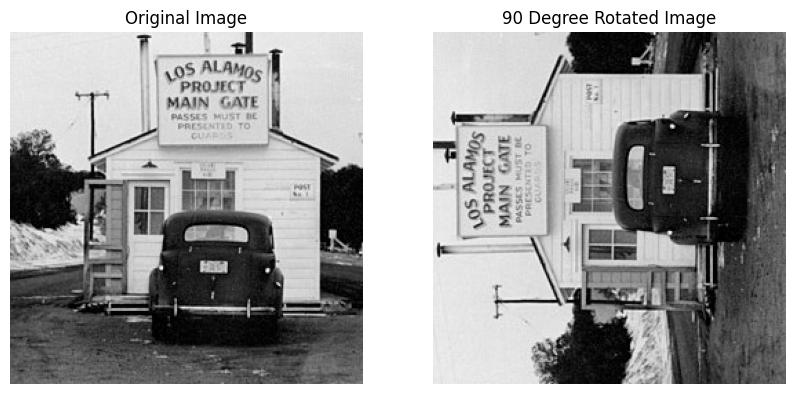

In [66]:
# Testing images
import torch 
from torchvision import transforms
from hippy2d.utils import get_testing_img, get_default_complex
# Set default to double precision
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Simulate RGB channels
test_img = get_testing_img(rgb=False)
test_img = transforms.ToTensor()(test_img).to(dtype=torch.float64)
rotated_img = torch.rot90(test_img, 1, [1, 2])
# 
test_rgb_img = get_testing_img(rgb=True)
test_rgb_img = transforms.ToTensor()(test_rgb_img).to(dtype=torch.float64)
rotated_rgb_img = torch.rot90(test_img, 1, [1, 2])
# Plot the images
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_img.permute(1, 2, 0).numpy(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(rotated_img.permute(1, 2, 0).numpy(), cmap='gray')
plt.title("90 Degree Rotated Image",)
plt.axis('off')
plt.show()

In [67]:
# Plot the filters
flex_filters = torch.view_as_complex(rearrange(flex.filters, '(co m) 1 h w -> m h w co', co=2).contiguous())
flusser_filters = torch.view_as_complex(rearrange(flusser.filters, '(co m) 1 h w -> m h w co', co=2).contiguous())

In [68]:
flex_moments, flex_invariants  = flex(test_rgb_img[None].to(device))
flex_moments = rearrange(flex_moments[0], '(co m) h w -> m h w co', co=2).contiguous()
flex_invariants = flex_invariants[0]

flusser_moments, flusser_invariants, norm_factor  = flusser(test_rgb_img[None].to(device))
flusser_moments = rearrange(flusser_moments[0], '(co m) h w -> m h w co', co=2).contiguous()
flusser_invariants = rearrange(flusser_invariants[0], '(co m) h w -> m h w co', co=2).contiguous()

In [69]:
torch.testing.assert_close(flex_moments[0], flusser_moments[1]) 
torch.testing.assert_close(flusser_moments[0] * flex._conj, flex_moments[3])
torch.testing.assert_close(flex_moments[1], flusser_moments[3])
torch.testing.assert_close(flex_moments[2], flusser_moments[6])
torch.testing.assert_close(flex_moments[3], flusser_moments[2])
torch.testing.assert_close(flex_moments[4], flusser_moments[4])
torch.testing.assert_close(flex_moments[5], flusser_moments[5])
torch.testing.assert_close(flex_moments[6], flusser_moments[7])
torch.testing.assert_close(flex_moments[7], flusser_moments[8])
torch.testing.assert_close(flex_moments[8], flusser_moments[9]) 

In [75]:
flex_moments.shape

torch.Size([9, 256, 256, 2])

In [71]:
weights = torch.softmax(torch.norm(flex_moments, dim=-1), dim=0)
weights = repeat(weights, 'm h w -> n m h w', n=9)
weights.shape

torch.Size([9, 9, 256, 256])

In [ ]:
nonsymmetric = flex_moments[len(flex.symmetric_polynomials):]

a = complex_power_moivre(nonsymmetric[:, None],
                        flex.exp_a[..., None, None],
                        magnitude_func="copy",
                        safe_magnitude_power=False) # Note: There are not zero exponents
# Make conjugate 
b = complex_power_moivre(nonsymmetric[None, :] * flex._conj,
                        flex.exp_b[..., None, None],
                        magnitude_func="copy",
                        safe_magnitude_power=False) # Note: There are not zero exponents

# Make a complex multiplication between new_a and new_b
nonsymmetric_real = (a[..., 0] * b[..., 0] - a[..., 1] * b[..., 1])
nonsymmetric_imag = (a[..., 0] * b[..., 1] + a[..., 1] * b[..., 0])



In [89]:
a.shape

torch.Size([6, 6, 256, 256, 2])

In [90]:
b.shape

torch.Size([6, 6, 256, 256, 2])

In [ ]:
.shape

torch.Size([6, 256, 256, 2])

In [92]:
flex.symmetric_polynomials.shape

torch.Size([3, 2])

In [113]:

weights = torch.softmax(torch.norm(flex_moments[flex.symmetric_polynomials.shape[0]:], dim=-1), dim=0)
weights = repeat(weights, 'm h w -> n m h w', n=6)
 
(nonsymmetric_real * weights).sum(dim=0).shape

torch.Size([6, 256, 256])